# Train delays

## Importing necessary libraries

In [1484]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Project background

The reason for choosing this dataset is because of today's world where trains are being more and more delayed, during some period of the day or during the whole day of the weekdays. This is happening more frequently, and that is why it would be interesting to explore the affection of delayed trains because of factors such as weather conditions, and route congestion during the days' different periods. Additionally, more and more people are taking the train when traveling, but foremost when taking the train to go to their workplace, where train delays plays an important part that could have an impact on people's schedules. This topic is a regression problem where the historic delay in minutes, in this case is the target variable, is a value that is continous. The aim is to predict the train delays and understand the factors that are affecting the train delays by utilzing and applying different models on the dataset to compare and choose the best model to use at last. The models that have been chosen were such as Random Forest, Ridge Regression, Decision Tree, and XGBoost. While other models such as Linear Regression could have been included, some of the chosen ones are known for their performance when the dataset is complex, and their ability of handling data that are noisy. Interesting things to explore as hypotheses would be such as:

* High route congestion increases the train delays
* Train delays are higher when the weather condition is bad
* Mornings has higher route congestion than the other time periods during the days

Interesting questions to explore would be:
* How is the route congestion correlated with the train delays?
* Do the train delays differ between when the weather is clear, and when the weather is bad? 
* Do the route congestion vary among the different time periods during the day?

The dataset that has been chosen contains data that consist historic train delays where factors that could have an impact is included such as the weather condition, the timeperiod during the days, the weekdays, and the route congestion. By exploring this dataset, the questions will be answered and the purpose of this project will be reached through preparing the data, visualizing the data, and modeling in order to predict the train delays, and also evaluate which model that suits best and is seen as the suitable model for predicting train delays.

## Import and read the dataset as a csv file

In [1486]:
df = pd.read_csv("train delay data.csv")

### Overview of the imported dataset/Exploring the dataset

In [1488]:
#Checking what kind of columns the dataset contains within the index
df.columns

Index(['Distance Between Stations (km)', 'Weather Conditions',
       'Day of the Week', 'Time of Day', 'Train Type',
       'Historical Delay (min)', 'Route Congestion'],
      dtype='object')

In [1490]:
#Checking how the data looks during a week
df.head(8)

,Distance Between Stations (km),Weather Conditions,Day of the Week,Time of Day,Train Type,Historical Delay (min),Route Congestion
0,100,Clear,Monday,Morning,Express,5,Low
1,150,Rainy,Tuesday,Afternoon,Superfast,10,Medium
2,200,Foggy,Wednesday,Evening,Local,15,High
3,50,Clear,Thursday,Night,Express,2,Low
4,75,Rainy,Friday,Morning,Superfast,8,Medium
5,125,Foggy,Saturday,Afternoon,Local,20,High
6,90,Clear,Sunday,Evening,Express,0,Low
7,60,Rainy,Monday,Night,Superfast,12,Medium


In [1492]:
#Checking what data type each column is within the dataset
df.dtypes

Distance Between Stations (km)     int64
Weather Conditions                object
Day of the Week                   object
Time of Day                       object
Train Type                        object
Historical Delay (min)             int64
Route Congestion                  object
dtype: object

In [1494]:
#Checking how many rows, and how many columns the dataset have
df.shape

(2878, 7)

In [1496]:
#View of the 15 rows to look at how the data varies of the first two weeks
df.head(14)

,Distance Between Stations (km),Weather Conditions,Day of the Week,Time of Day,Train Type,Historical Delay (min),Route Congestion
0,100,Clear,Monday,Morning,Express,5,Low
1,150,Rainy,Tuesday,Afternoon,Superfast,10,Medium
2,200,Foggy,Wednesday,Evening,Local,15,High
3,50,Clear,Thursday,Night,Express,2,Low
4,75,Rainy,Friday,Morning,Superfast,8,Medium
5,125,Foggy,Saturday,Afternoon,Local,20,High
6,90,Clear,Sunday,Evening,Express,0,Low
7,60,Rainy,Monday,Night,Superfast,12,Medium
8,110,Clear,Tuesday,Morning,Local,3,High
9,95,Foggy,Wednesday,Afternoon,Express,25,Low


In [1498]:
#Now I want to explore how many unique values the dataset have in each column
df.nunique()

Distance Between Stations (km)    190
Weather Conditions                  3
Day of the Week                     7
Time of Day                         4
Train Type                          3
Historical Delay (min)            428
Route Congestion                    3
dtype: int64

In [1500]:
#Looking and detecting if there are missing values or values that contain null
df.isna()

,Distance Between Stations (km),Weather Conditions,Day of the Week,Time of Day,Train Type,Historical Delay (min),Route Congestion
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
2873,False,False,False,False,False,False,False
2874,False,False,False,False,False,False,False
2875,False,False,False,False,False,False,False
2876,False,False,False,False,False,False,False


In [1237]:
#Looks like there are only false values = no missing values or values that contain null 
#Explicitly looking and counting if there are any true values in the dataset just to make sure not to miss any

In [1502]:
def is_missing_value(df):
    if df.isna().values.any():
        print(f'{df.isna().values().sum()} missing values found')
    else: 
        print('No missing values found within the dataset')

is_missing_value(df)

No missing values found within the dataset


In [1504]:
df.describe()

,Distance Between Stations (km),Historical Delay (min)
count,2878.000000,2878.000000
mean,184.423211,93.324878
std,169.394783,195.923817
min,0.000000,0.000000
25%,70.000000,13.000000
50%,155.000000,35.000000
75%,225.000000,74.000000
max,955.000000,1230.000000


In [1506]:
#Looking for any duplicates within the dataset
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2873    False
2874    False
2875    False
2876    False
2877    False
Length: 2878, dtype: bool

In [1508]:
#Renaming columns for facilitating better when it comes to the labels

df.rename(columns = {
                            'Distance Between Stations (km)': 'station_distance_km',
                            'Weather Conditions': 'weather_condition',
                            'Day of the Week': 'weekday',
                            'Time of Day': 'time_during_day',
                            'Train Type': 'train_type',
                            'Historical Delay (min)': 'delay_in_min',
                            'Route Congestion': 'route_congestion'
                    }, inplace = True)

In [1510]:
#Changing the order to visualize it better 

df = df[['delay_in_min', 'weekday', 'time_during_day', 'train_type', 'weather_condition', 'route_congestion', 'station_distance_km']]

In [1512]:
print(df.to_string())

      delay_in_min    weekday time_during_day train_type weather_condition route_congestion  station_distance_km
0                5     Monday         Morning    Express             Clear              Low                  100
1               10    Tuesday       Afternoon  Superfast             Rainy           Medium                  150
2               15  Wednesday         Evening      Local             Foggy             High                  200
3                2   Thursday           Night    Express             Clear              Low                   50
4                8     Friday         Morning  Superfast             Rainy           Medium                   75
5               20   Saturday       Afternoon      Local             Foggy             High                  125
6                0     Sunday         Evening    Express             Clear              Low                   90
7               12     Monday           Night  Superfast             Rainy           Medium     

In [1514]:
#Checking the changes
df.head(7)

,delay_in_min,weekday,time_during_day,train_type,weather_condition,route_congestion,station_distance_km
0,5,Monday,Morning,Express,Clear,Low,100
1,10,Tuesday,Afternoon,Superfast,Rainy,Medium,150
2,15,Wednesday,Evening,Local,Foggy,High,200
3,2,Thursday,Night,Express,Clear,Low,50
4,8,Friday,Morning,Superfast,Rainy,Medium,75
5,20,Saturday,Afternoon,Local,Foggy,High,125
6,0,Sunday,Evening,Express,Clear,Low,90


# Exploratory Data Analysis

<Axes: xlabel='delay_in_min'>

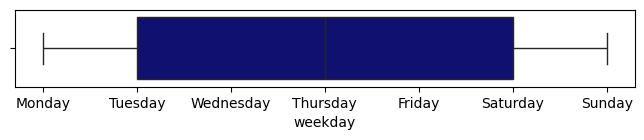

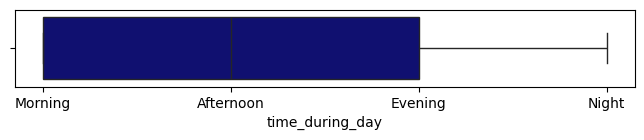

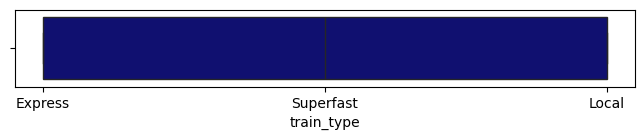

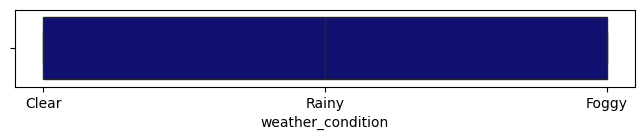

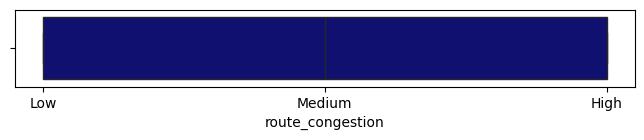

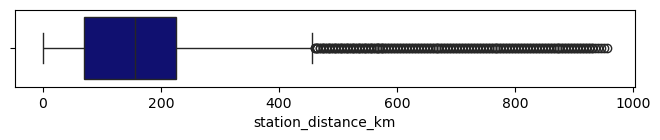

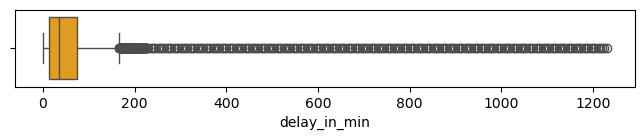

In [1255]:
plt.figure(figsize = (8,1))
sns.boxplot(data = df, x = 'weekday', color = 'navy')
plt.figure(figsize = (8,1))
sns.boxplot(data = df, x = 'time_during_day', color = 'navy')
plt.figure(figsize = (8,1))
sns.boxplot(data = df, x = 'train_type', color = 'navy')
plt.figure(figsize = (8,1))
sns.boxplot(data = df, x = 'weather_condition', color = 'navy')
plt.figure(figsize = (8,1))
sns.boxplot(data = df, x = 'route_congestion', color = 'navy')
plt.figure(figsize = (8,1))
sns.boxplot(data = df, x = 'station_distance_km', color = 'navy')
plt.figure(figsize = (8,1))
sns.boxplot(data = df, x = 'delay_in_min', color = 'orange')

<Axes: xlabel='delay_in_min'>

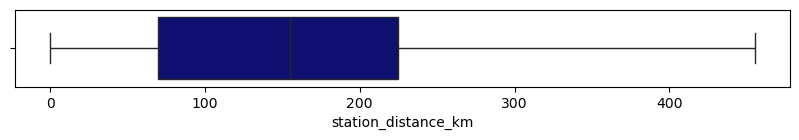

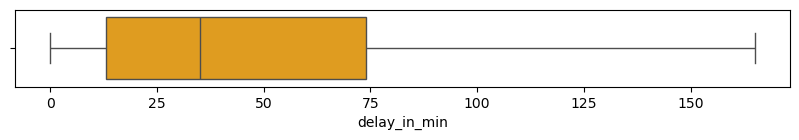

In [1516]:
#Visualizing the boxplots without the outliers to see how it looks without them and what the
#estimated distance between stations in km, and the estimated delay in minutes could be 
plt.figure(figsize = (10,1))
sns.boxplot(data = df, x = 'station_distance_km', color = 'navy', showfliers = False)
plt.figure(figsize = (10,1))
sns.boxplot(data = df, x = 'delay_in_min', color = 'orange', showfliers = False)

In [1518]:
#Finding the quantile of 25% and 75%, and also checking the range of interquartile for the 
#difference among the third quantile and the second quantile
q1_25 = df['delay_in_min'].quantile(0.25)
q3_75 = df['delay_in_min'].quantile(0.75)
iqr = q3_75 - q1_25

In [1520]:
print(q1_25, q3_75, iqr)

13.0 74.0 61.0


In [1522]:
#Checking the first and second quantile values if it is correct
df['delay_in_min'].describe()

count    2878.000000
mean       93.324878
std       195.923817
min         0.000000
25%        13.000000
50%        35.000000
75%        74.000000
max      1230.000000
Name: delay_in_min, dtype: float64

In [1524]:
#Looks like 25% of all the data equals to delays of 13 minutes or lower
#while, 75% of all the data equals to delays of 74 minutes or lower 

In [1526]:
#Checking how many trains that were on time and where there was no delay
df.query('delay_in_min == 0')

,delay_in_min,weekday,time_during_day,train_type,weather_condition,route_congestion,station_distance_km
6,0,Sunday,Evening,Express,Clear,Low,90
12,0,Saturday,Morning,Express,Clear,Low,160
32,0,Friday,Morning,Local,Clear,Low,155
47,0,Saturday,Night,Local,Clear,Low,90
50,0,Tuesday,Morning,Local,Clear,Medium,190
...,...,...,...,...,...,...,...
2367,0,Monday,Night,Local,Clear,Medium,250
2376,0,Wednesday,Morning,Local,Clear,Medium,240
2385,0,Friday,Afternoon,Local,Clear,Medium,230
2394,0,Sunday,Evening,Local,Clear,Medium,215


In [1528]:
#Checking how many trains that had a delay under or equal to 74 minutes
df.query('delay_in_min <= 74.0')

,delay_in_min,weekday,time_during_day,train_type,weather_condition,route_congestion,station_distance_km
0,5,Monday,Morning,Express,Clear,Low,100
1,10,Tuesday,Afternoon,Superfast,Rainy,Medium,150
2,15,Wednesday,Evening,Local,Foggy,High,200
3,2,Thursday,Night,Express,Clear,Low,50
4,8,Friday,Morning,Superfast,Rainy,Medium,75
...,...,...,...,...,...,...,...
2641,50,Monday,Night,Superfast,Foggy,Low,365
2642,55,Tuesday,Morning,Local,Clear,Medium,345
2643,60,Wednesday,Afternoon,Express,Rainy,High,370
2644,65,Thursday,Evening,Superfast,Foggy,Low,350


In [1530]:
#Checking how many trains that had a delay over 74 minutes
df.query('delay_in_min > 74.0')

,delay_in_min,weekday,time_during_day,train_type,weather_condition,route_congestion,station_distance_km
811,75,Tuesday,Afternoon,Superfast,Foggy,Low,190
814,76,Friday,Morning,Superfast,Foggy,Low,180
817,77,Monday,Night,Superfast,Foggy,Low,190
820,78,Thursday,Evening,Superfast,Foggy,Low,180
823,79,Sunday,Afternoon,Superfast,Foggy,Low,190
...,...,...,...,...,...,...,...
2873,1210,Tuesday,Night,Local,Clear,Medium,945
2874,1215,Wednesday,Morning,Express,Rainy,High,925
2875,1220,Thursday,Afternoon,Superfast,Foggy,Low,950
2876,1225,Friday,Evening,Local,Clear,Medium,930


In [1532]:
#For the whole dataset, there are 2878 rows, 718 rows have over 74.0 minutes in delays,
#where these ones were seen as outliers. 718 / 2878 = 0.25, which means that if these ones
#would be removed, 25% of the data would be removed which is a lot and would result in data loss
#limit the performance. Generally it seems like train delays over 74 minutes would be extreme
#extreme values, and may be because of accidents or failures of the trains, where if a train
#would be cancelled and people would be referred to take the next train instead of the train
#being delayed for so much minutes.

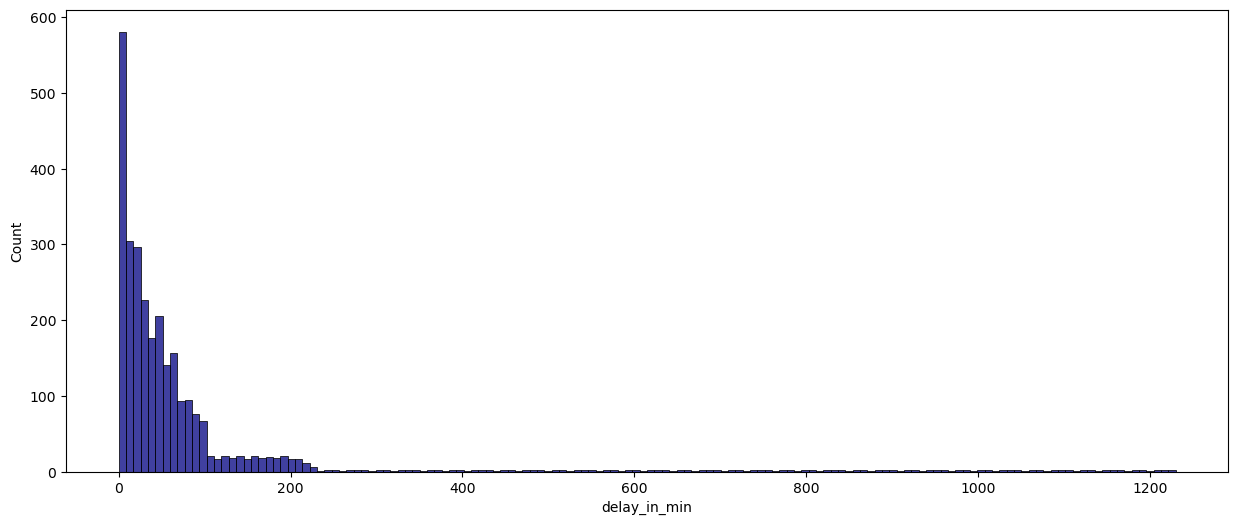

In [1536]:
#Checking how the minutes for the delayed trains varies
df.query('delay_in_min <= 74.0')
plt.figure(figsize = (15,6))
sns.histplot(x = 'delay_in_min', data = df, color = 'navy')
plt.show()

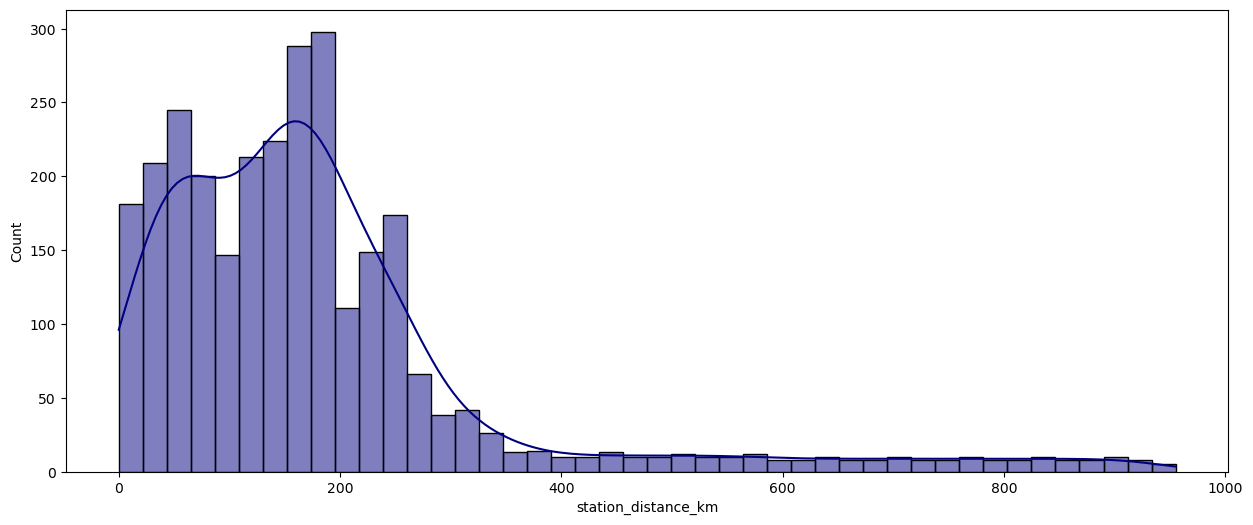

In [1538]:
#Checking how the distance between stations differ in kilometers
plt.figure(figsize = (15,6))
sns.histplot(x = 'station_distance_km', data = df, color = 'navy', kde = True)
plt.show()

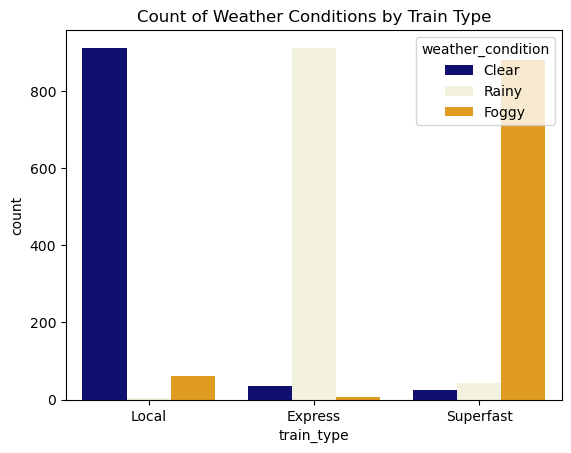

In [1283]:
#Visualizing how often the weather has been clear/rainy/foggy for each train type
sns.countplot(x='train_type', hue='weather_condition', data=df, order=['Local', 'Express', 'Superfast'], palette = ['navy', 'beige', 'orange'])
plt.title('Count of Weather Conditions by Train Type')
plt.show()

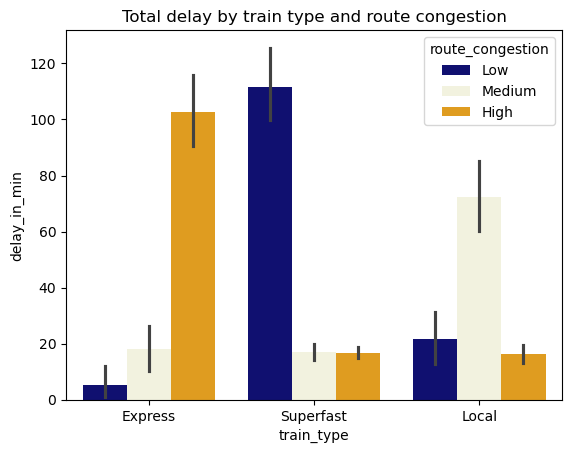

In [1544]:
#Comparing the route congestion on the different train types in conjunction 
#with the total delay in minutes
sns.barplot(x = 'train_type', y = 'delay_in_min', hue = 'route_congestion', data = df, palette = ['navy', 'beige', 'orange'])
plt.title('Total delay by train type and route congestion')
plt.show()

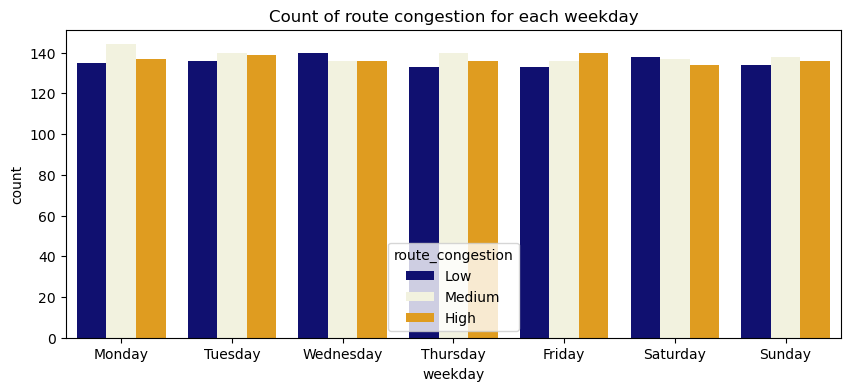

In [1546]:
#Visualizing the amount of route congestion that has been within each weekday
plt.figure(figsize = (10,4))
sns.countplot(x = 'weekday', hue = 'route_congestion', data = df, order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette = ['navy', 'beige', 'orange'])
plt.title('Count of route congestion for each weekday')
plt.show()

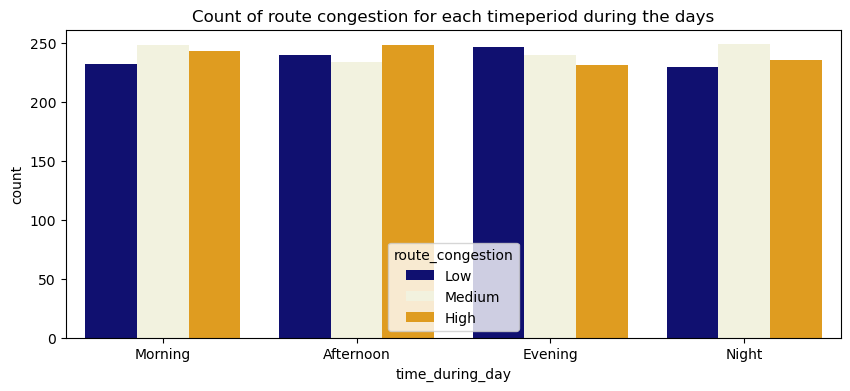

In [1548]:
#Visualizing the route congestion for the different times during the days
plt.figure(figsize = (10,4))
sns.countplot(x = 'time_during_day', hue = 'route_congestion', data = df, palette = ['navy', 'beige', 'orange'])
plt.title('Count of route congestion for each timeperiod during the days')
plt.show()

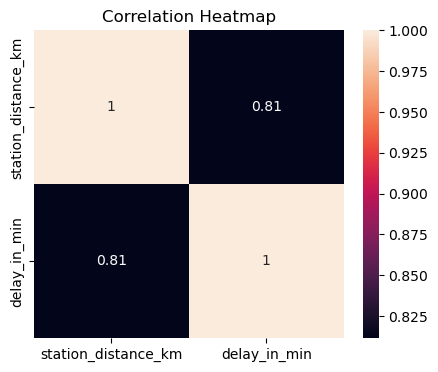

In [1295]:
#Looking at the correlation between the numerical values
plt.figure(figsize = (5,4))
sns.heatmap(df[['station_distance_km', 'delay_in_min']].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

# Preprocessing

## One Hot Encoder

In [1550]:
#Importing the OneHotEncoder for the nominal data within the categorical variables before modeling
#weather_condition to:
#weather_condition_clear
#weather_condition_foggy
#weather_condition_rainy

#train_type to:
#train_type_local
#train_type_express
#train_type_superfast
from sklearn.preprocessing import OneHotEncoder

In [1552]:
enc_onh_weather = OneHotEncoder(sparse_output = False).set_output(transform = 'pandas')

In [1554]:
enc_onh_transform_weather = enc_onh_weather.fit_transform(df[['weather_condition']])

In [1556]:
df = pd.concat([df, enc_onh_transform_weather], axis = 1)

In [1558]:
enc_onh_train_type = OneHotEncoder(sparse_output = False).set_output(transform = 'pandas')

In [1560]:
enc_onh_transform_train_type = enc_onh_train_type.fit_transform(df[['train_type']])

In [1562]:
df = pd.concat([df, enc_onh_transform_train_type], axis = 1)

## Ordinal Encoder

In [1564]:
#Importing the Ordinal Encoder for the ordinal data within the categorical variables before modeling
#weekday to:
#Monday = 1.0
#Tuesday = 2.0
#Wednesday = 3.0
#Thursday = 4.0
#Friday = 5.0
#Saturday = 6.0
#Sunday = 7.0

#time_during_day to:
#time_during_day_morning
#time_during_day_afternoon
#time_during_day_evening
#time_during_day_night

#route_congestion to:
#route_congestion_low
#route_congestion_medium
#route_congestion_high

from sklearn.preprocessing import OrdinalEncoder

In [1566]:
enc_ord_weekday = OrdinalEncoder(categories = [['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                                                'Friday', 'Saturday', 'Sunday']])

In [1568]:
df['weekday'] = enc_ord_weekday.fit_transform(df[['weekday']])

In [1570]:
enc_ord_time_during_day = OrdinalEncoder(categories = [['Morning', 'Afternoon', 'Evening', 'Night']])

In [1572]:
df['time_during_day'] = enc_ord_time_during_day.fit_transform(df[['time_during_day']])

In [1574]:
enc_ord_route_congestion = OrdinalEncoder(categories = [['Low', 'Medium', 'High']])

In [1576]:
df['route_congestion'] = enc_ord_route_congestion.fit_transform(df[['route_congestion']])

In [1578]:
#Checking the dataset after the encoders One Hot Encoder, and Ordinal Encoder have been used
df

,delay_in_min,weekday,time_during_day,train_type,weather_condition,route_congestion,station_distance_km,weather_condition_Clear,weather_condition_Foggy,weather_condition_Rainy,train_type_Express,train_type_Local,train_type_Superfast
0,5,0.0,0.0,Express,Clear,0.0,100,1.0,0.0,0.0,1.0,0.0,0.0
1,10,1.0,1.0,Superfast,Rainy,1.0,150,0.0,0.0,1.0,0.0,0.0,1.0
2,15,2.0,2.0,Local,Foggy,2.0,200,0.0,1.0,0.0,0.0,1.0,0.0
3,2,3.0,3.0,Express,Clear,0.0,50,1.0,0.0,0.0,1.0,0.0,0.0
4,8,4.0,0.0,Superfast,Rainy,1.0,75,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2873,1210,1.0,3.0,Local,Clear,1.0,945,1.0,0.0,0.0,0.0,1.0,0.0
2874,1215,2.0,0.0,Express,Rainy,2.0,925,0.0,0.0,1.0,1.0,0.0,0.0
2875,1220,3.0,1.0,Superfast,Foggy,0.0,950,0.0,1.0,0.0,0.0,0.0,1.0
2876,1225,4.0,2.0,Local,Clear,1.0,930,1.0,0.0,0.0,0.0,1.0,0.0


In [1580]:
#Dropping the categorical type of columns that have been encoded
df = df.drop(['train_type', 'weather_condition'], axis = 1)

In [1582]:
#Checking the changes
df

,delay_in_min,weekday,time_during_day,route_congestion,station_distance_km,weather_condition_Clear,weather_condition_Foggy,weather_condition_Rainy,train_type_Express,train_type_Local,train_type_Superfast
0,5,0.0,0.0,0.0,100,1.0,0.0,0.0,1.0,0.0,0.0
1,10,1.0,1.0,1.0,150,0.0,0.0,1.0,0.0,0.0,1.0
2,15,2.0,2.0,2.0,200,0.0,1.0,0.0,0.0,1.0,0.0
3,2,3.0,3.0,0.0,50,1.0,0.0,0.0,1.0,0.0,0.0
4,8,4.0,0.0,1.0,75,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2873,1210,1.0,3.0,1.0,945,1.0,0.0,0.0,0.0,1.0,0.0
2874,1215,2.0,0.0,2.0,925,0.0,0.0,1.0,1.0,0.0,0.0
2875,1220,3.0,1.0,0.0,950,0.0,1.0,0.0,0.0,0.0,1.0
2876,1225,4.0,2.0,1.0,930,1.0,0.0,0.0,0.0,1.0,0.0


## Train/Test split the data into X and y

In [1584]:
X = df.iloc[:,1:11]

In [1586]:
y = df.iloc[:,0]

In [1588]:
X.head()

,weekday,time_during_day,route_congestion,station_distance_km,weather_condition_Clear,weather_condition_Foggy,weather_condition_Rainy,train_type_Express,train_type_Local,train_type_Superfast
0,0.0,0.0,0.0,100,1.0,0.0,0.0,1.0,0.0,0.0
1,1.0,1.0,1.0,150,0.0,0.0,1.0,0.0,0.0,1.0
2,2.0,2.0,2.0,200,0.0,1.0,0.0,0.0,1.0,0.0
3,3.0,3.0,0.0,50,1.0,0.0,0.0,1.0,0.0,0.0
4,4.0,0.0,1.0,75,0.0,0.0,1.0,0.0,0.0,1.0


In [1590]:
y.head()

0     5
1    10
2    15
3     2
4     8
Name: delay_in_min, dtype: int64

In [1592]:
#Importing train test split for splitting the data in two sets, one for training and one for testing
from sklearn.model_selection import train_test_split

In [1594]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 19)

In [1596]:
#Checking the shapes of the splited dataset
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2302, 10)
(2302,)
(576, 10)
(576,)


In [1598]:
X_train.describe()

,weekday,time_during_day,route_congestion,station_distance_km,weather_condition_Clear,weather_condition_Foggy,weather_condition_Rainy,train_type_Express,train_type_Local,train_type_Superfast
count,2302.000000,2302.000000,2302.000000,2302.000000,2302.000000,2302.000000,2302.000000,2302.000000,2302.000000,2302.000000
mean,2.961772,1.501303,0.995656,183.935708,0.339705,0.331885,0.328410,0.326238,0.344483,0.329279
std,1.986551,1.116721,0.811145,170.716837,0.473712,0.470992,0.469737,0.468937,0.475303,0.470053
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,2.000000,1.000000,155.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,2.000000,2.000000,220.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,6.000000,3.000000,2.000000,955.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [1600]:
X_test.describe()

,weekday,time_during_day,route_congestion,station_distance_km,weather_condition_Clear,weather_condition_Foggy,weather_condition_Rainy,train_type_Express,train_type_Local,train_type_Superfast
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,3.085069,1.470486,1.032986,186.371528,0.328125,0.319444,0.352431,0.352431,0.315972,0.331597
std,2.062009,1.123270,0.826068,164.135238,0.469939,0.466667,0.478142,0.478142,0.465306,0.471196
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,75.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,1.000000,1.000000,160.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,2.000000,2.000000,230.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,6.000000,3.000000,2.000000,930.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [1602]:
y_train.describe()

count    2302.000000
mean       94.154648
std       198.533118
min         0.000000
25%        13.000000
50%        35.000000
75%        74.750000
max      1230.000000
Name: delay_in_min, dtype: float64

In [1604]:
y_test.describe()

count     576.000000
mean       90.008681
std       185.257419
min         0.000000
25%        13.000000
50%        36.000000
75%        73.250000
max      1225.000000
Name: delay_in_min, dtype: float64

In [1606]:
#Importing the StandardScaler for scaling the the data
from sklearn.preprocessing import StandardScaler

In [1608]:
stscal = StandardScaler()

In [1610]:
X_train = stscal.fit_transform(X_train)

In [1612]:
X_test = stscal.transform(X_test)

# Modeling

In [1614]:
#Importing the selected and chosen models for this dataset to be utilized
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

## Random Forest

In [1616]:
rfreg = RandomForestRegressor()

In [1618]:
rfreg.fit(X_train, y_train)

RandomForestRegressor()

In [1620]:
y_pred_rfreg = rfreg.predict(X_test)

In [1622]:
rfreg.score(X_test, y_test)

0.9332459655197334

## Linear Regression

In [1624]:
ridreg = Ridge()

In [1626]:
ridreg.fit(X_train, y_train)

Ridge()

In [1628]:
y_pred_ridreg = ridreg.predict(X_test)

In [1630]:
ridreg.score(X_test, y_test)

0.6501235378887944

## Decision Trees

In [1632]:
dtreg = DecisionTreeRegressor()

In [1634]:
dtreg.fit(X_train, y_train)

DecisionTreeRegressor()

In [1636]:
y_pred_dtreg = dtreg.predict(X_test)

In [1638]:
dtreg.score(X_test, y_test)

0.8749261143495872

## XGBoost

In [1640]:
xgb_reg = XGBRegressor()

In [1642]:
xgb_reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [1644]:
y_pred_xgb_reg = xgb_reg.predict(X_test)

In [1646]:
xgb_reg.score(X_test, y_test)

0.9291893273296817

# Evaluating performance

In [1648]:
#Importing needed metrics for evaluating regression models
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [1650]:
#Comparing and evaluating the different models' based on the metrics
#Mean Absolute Error
def view_mae_compare():
    print(f'Mean Absolute Error: ')
    print(f'Random Forest: {mean_absolute_error(y_test, y_pred_rfreg)}')
    print(f'Ridge Regression: {mean_absolute_error(y_test, y_pred_ridreg)}')
    print(f'Decision Tree: {mean_absolute_error(y_test, y_pred_dtreg)}')
    print(f'XGBoost: {mean_absolute_error(y_test, y_pred_xgb)}\n')

#Mean Squared Error
def view_mse_compare():
    print(f'Mean Squared Error: ')
    print(f'Random Forest: {mean_squared_error(y_test, y_pred_rfreg)}')
    print(f'Ridge Regression: {mean_squared_error(y_test, y_pred_ridreg)}')
    print(f'Decision Tree: {mean_squared_error(y_test, y_pred_dtreg)}')
    print(f'XGBoost: {mean_squared_error(y_test, y_pred_xgb)}\n')

#R^2
def view_r2_compare():
    print(f'R2: ')
    print(f'Random Forest: {r2_score(y_test, y_pred_rfreg)}')
    print(f'Ridge Regression: {r2_score(y_test, y_pred_ridreg)}')
    print(f'Decision Tree: {r2_score(y_test, y_pred_dtreg)}')
    print(f'XGBoost: {r2_score(y_test, y_pred_xgb)}\n')

view_mae_compare()
view_mse_compare()
view_r2_compare()

Mean Absolute Error: 
Random Forest: 28.968632353865043
Ridge Regression: 88.90217390984478
Decision Tree: 34.93802083333333
XGBoost: 29.339895559216124

Mean Squared Error: 
Random Forest: 2287.0417751882683
Ridge Regression: 11987.022076395206
Decision Tree: 4285.122295524692
XGBoost: 2426.025150196334

R2: 
Random Forest: 0.9332459655197334
Ridge Regression: 0.6501235378887944
Decision Tree: 0.8749261143495872
XGBoost: 0.9291893273296817



##  Hyperparameter tuning

In [1415]:
#Checking the parameters that exist for every model, and thereafter adjusting with selected hyperparameters

In [1652]:
rfreg.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [1654]:
param_grid_rfreg = [{
                        'n_estimators': [100, 200, 300],
                        'min_samples_split': [2, 5, 10]
                    }]

In [1656]:
ridreg.get_params()

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': None,
 'solver': 'auto',
 'tol': 0.0001}

In [1658]:
param_grid_ridreg = [{
                        'alpha': [0.1, 1.0, 10.0],
                        'solver': ['svd', 'saga', 'auto']
                    }]

In [1660]:
dtreg.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [1662]:
param_grid_dtreg = [{
                        'max_depth': [4, 7, 10],
                        'min_samples_split': [3, 5, 8]
                    }]

In [1664]:
xgb_reg.get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [1666]:
param_grid_xgb_reg = [{
                        'max_depth': [5, 7, 9],
                        'n_estimators': [100, 150, 170]
                    }]

## GridSearchCV

In [1435]:
#Importing the technique of cross validation which in this case is GridSearchCV, in order to 
#perform hyperparameter tuning and finding the best seen hyperparameters

In [1668]:
from sklearn.model_selection import GridSearchCV

In [1670]:
#For Random Forest
rfreg_CV = GridSearchCV(rfreg, cv = 3, param_grid = param_grid_rfreg, n_jobs = -1)

In [1672]:
rfreg_CV.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid=[{'min_samples_split': [2, 5, 10],
                          'n_estimators': [100, 200, 300]}])

In [1674]:
best_rfreg_CV = rfreg_CV.best_estimator_

In [1676]:
y_pred_rfreg_CV = best_rfreg_CV.predict(X_test)

In [1120]:
#For Ridge Regression

In [1678]:
ridreg_CV = GridSearchCV(ridreg, cv = 3, param_grid = param_grid_ridreg, n_jobs = -1)

In [1680]:
ridreg_CV.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=Ridge(), n_jobs=-1,
             param_grid=[{'alpha': [0.1, 1.0, 10.0],
                          'solver': ['svd', 'saga', 'auto']}])

In [1682]:
best_ridreg_CV = ridreg_CV.best_estimator_

In [1684]:
y_pred_ridreg_CV = best_ridreg_CV.predict(X_test)

In [1686]:
#For Decision Tree
dtreg_CV = GridSearchCV(dtreg, cv = 3, param_grid = param_grid_dtreg, n_jobs = -1)

In [1688]:
dtreg_CV.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid=[{'max_depth': [4, 7, 10],
                          'min_samples_split': [3, 5, 8]}])

In [1690]:
best_dtreg_CV = dtreg_CV.best_estimator_

In [1692]:
y_pred_dtreg_CV = best_dtreg_CV.predict(X_test)

In [1694]:
#For XGBoost
xgb_reg_CV = GridSearchCV(xgb_reg, cv = 3, param_grid = param_grid_xgb_reg, n_jobs = -1)

In [1696]:
xgb_reg_CV.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             n_jobs=-1,
             param_grid=[{'max_depth': [5, 7, 9],
                          'n_estimators': [100, 150, 170]}])

In [1698]:
best_xgb_reg_CV = xgb_reg_CV.best_estimator_

In [1700]:
y_pred_xgb_reg_CV = best_xgb_reg_CV.predict(X_test)

## Results comparison regarding before and after being optimized

In [1702]:
#Comparing the results of the different models before and after being optimized with GridSearchCV

#Before being optimized
print('Result performance before: \n')
print(f'Mean Absolute Error: ')
print(f'Random Forest: {mean_absolute_error(y_test, y_pred_rfreg)}')
print(f'Ridge Regression: {mean_absolute_error(y_test, y_pred_ridreg)}')
print(f'Decision Tree: {mean_absolute_error(y_test, y_pred_dtreg)}')
print(f'XGBoost: {mean_absolute_error(y_test, y_pred_xgb_reg)}\n')

print(f'Mean Squared Error: ')
print(f'Random Forest: {mean_squared_error(y_test, y_pred_rfreg)}')
print(f'Ridge Regression: {mean_squared_error(y_test, y_pred_ridreg)}')
print(f'Decision Tree: {mean_squared_error(y_test, y_pred_dtreg)}')
print(f'XGBoost: {mean_squared_error(y_test, y_pred_xgb_reg)}\n')

print(f'R2: ')
print(f'Random Forest: {r2_score(y_test, y_pred_rfreg)}')
print(f'Ridge Regression: {r2_score(y_test, y_pred_ridreg)}')
print(f'Decision Tree: {r2_score(y_test, y_pred_dtreg)}')
print(f'XGBoost: {r2_score(y_test, y_pred_xgb_reg)}\n\n')

#After being optimized
print('Result performance with hyperparameter tuning with GridSearchCV: \n')
print(f'Mean Absolute Error: ')
print(f'Random Forest: {mean_absolute_error(y_test, y_pred_rfreg_CV)}')
print(f'Ridge Regression: {mean_absolute_error(y_test, y_pred_ridreg_CV)}')
print(f'Decision Tree: {mean_absolute_error(y_test, y_pred_dtreg_CV)}')
print(f'XGBoost: {mean_absolute_error(y_test, y_pred_xgb_reg_CV)}\n')

print(f'Mean Squared Error: ')
print(f'Random Forest: {mean_squared_error(y_test, y_pred_rfreg_CV)}')
print(f'Ridge Regression: {mean_squared_error(y_test, y_pred_ridreg_CV)}')
print(f'Decision Tree: {mean_squared_error(y_test, y_pred_dtreg_CV)}')
print(f'XGBoost: {mean_squared_error(y_test, y_pred_xgb_reg_CV)}\n')

print(f'R2: ')
print(f'Random Forest: {r2_score(y_test, y_pred_rfreg_CV)}')
print(f'Ridge Regression: {r2_score(y_test, y_pred_ridreg_CV)}')
print(f'Decision Tree: {r2_score(y_test, y_pred_dtreg_CV)}')
print(f'XGBoost: {r2_score(y_test, y_pred_xgb_reg_CV)}\n')

Result performance before: 

Mean Absolute Error: 
Random Forest: 28.968632353865043
Ridge Regression: 88.90217390984478
Decision Tree: 34.93802083333333
XGBoost: 29.339895559216124

Mean Squared Error: 
Random Forest: 2287.0417751882683
Ridge Regression: 11987.022076395206
Decision Tree: 4285.122295524692
XGBoost: 2426.025150196334

R2: 
Random Forest: 0.9332459655197334
Ridge Regression: 0.6501235378887944
Decision Tree: 0.8749261143495872
XGBoost: 0.9291893273296817


Result performance with hyperparameter tuning with GridSearchCV: 

Mean Absolute Error: 
Random Forest: 28.365412858095194
Ridge Regression: 88.7642404807133
Decision Tree: 31.496728717735778
XGBoost: 28.4493186602162

Mean Squared Error: 
Random Forest: 1986.350648120745
Ridge Regression: 11973.718357436912
Decision Tree: 3198.3275661005937
XGBoost: 2116.047296074453

R2: 
Random Forest: 0.9420225196176678
Ridge Regression: 0.6505118460184021
Decision Tree: 0.9066474119786943
XGBoost: 0.9382369418449295



## Conclusions

The aim was to predict the train delays which could be depended on different factors such as different weather conditions or route congestions during different times through the days of the week, which could affect and vary between different type of trains. From the visualizations and the outcome of the used dataset, the questions have been answered where it can be seen that the route congestion is affecting the train delays. Fridays had the highest count of route congestion, where it can be said that there is a correlation between the train delays and route congestion. For the different timeperiods during the day, the afternoons had the highest route congestion count, where mornings were behind and were close but had a medium level of route congestion, where it varied for different timeperiods. Regarding the weather condition, the express trains and the superfast trains experienced more rainy and foggy weather than the local trains, and the train delays differed for different weather conditions, where delays were higher when it was bad weather. Another interesting result as an overview is that only 4% of the trains were on time, while 96% of the trains had been delayed for different amount of minutes which requires the train companies to consider this and think about the scheduling of trains, and be prepared for different weather conditions or route congestions. 

Looking at the results when it comes to the models' performances, there were similar results between the results before and after utilizing hyperparameter tuning and applying GridSearchCV. When looking at the mean absolute error before using GridSearchCV, Random Forest had the lowest value of 29.30, where XGBoost had a similar result with 29.34 and was really close. After applying GridSearchCV, the one that had the lowest mean absolute error was again Random Forest with 28.3, where XGBoost was behind it with 28.4. Regarding the mean squared error, the model that had the lowest value was Random Forest with 2380, and behind it XGBoost with 2426. After applying GridSearchCV, the one that had the lowest mean squared error was Random Forest again with 1985 where there was a small gap between the model and XGBoost that had 2116. Regarding the models' R2 score, the model that performed best was Random Forest with 0.93 and behind it XGBoost with 0.92. Afterwards, when having the GridSearchCV applied, all models had a minimum R2 score of 0.90 except for Ridge Regression that had 0.65, where the model that performed best of the other ones were Random Forest again with 0.94. 

In summary, it has been shown that the Random Forest model has been the one that has performed best with the XGBoost being close to it, while the Decision Tree have improved after applying GridSearchCV but being ouperformed by the other models, whereas Ridge Regression have performed bad possibly being affected by the outliers that were not removed due to it being 25% of the data, which as mentioned before could have resulted in data loss. For the results, it can be said that the Random Forest and also XGBoost performed high because of their less sensitivity to outliers and being robust. Thus, it would be interesting for future observations to see if Random Forest, and maybe also XGBoost, if they can have the same performance against neural networks, which could have been implemented in this case to compare. Additionally, RandomizedSearchCV may also be utilized to see how it affects the results, and also possibly increase the folds for the GridSearchCV before trying the RandomizedSearchCV. 